In [1]:
import string
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

# 1. Scraping Data Pemain NBA

In [2]:
all_players_data = []
headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML,'
        ' like Gecko) Chrome/120.0.0.0 Safari/537.36'
    )
}

print("Memulai proses scraping data pemain NBA A-Z...")

for letter in string.ascii_lowercase:
    url = f'https://www.basketball-reference.com/players/{letter}/'
    print(f"{'='*30}")
    print(f'Scraping data pemain huruf: {letter.upper()} -> {url}')
    print(f"{'='*30}\n")

    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')
        table = soup.find('table', {'id': 'players'})

        if table and table.find('tbody'):
            rows = table.find('tbody').find_all('tr')

            for row in rows:
                if row.find('th', {'scope': 'row'}) is None:
                    continue

                name_elem = row.find('th', {'data-stat': 'player'})
                name = name_elem.text.strip() if name_elem else None
                
                if name:
                    print(f"[SCRAPING] Player: {name}")

                from_year = row.find('td', {'data-stat': 'year_min'})
                to_year = row.find('td', {'data-stat': 'year_max'})
                pos = row.find('td', {'data-stat': 'pos'})
                height = row.find('td', {'data-stat': 'height'})
                weight = row.find('td', {'data-stat': 'weight'})
                birth_date = row.find('td', {'data-stat': 'birth_date'})
                colleges = row.find('td', {'data-stat': 'colleges'})

                all_players_data.append({
                    'player': name,
                    'from': from_year.text.strip() if from_year else None,
                    'to': to_year.text.strip() if to_year else None,
                    'pos': pos.text.strip() if pos else None,
                    'height': height.text.strip() if height else None,
                    'weight': weight.text.strip() if weight else None,
                    'birth_date': (
                        birth_date.text.strip() if birth_date else None
                    ),
                    'colleges': colleges.text.strip() if colleges else None,
                })
        else:
            print(f'Tabel tidak ditemukan untuk huruf {letter.upper()}')
    else:
        print(
            f'Gagal mengakses huruf {letter.upper()}, status code:'
            f' {response.status_code}'
        )

    time.sleep(3.5)
    
print('\nScraping Selesai!')
print(f'Total data berhasil diambil: {len(all_players_data)} baris.')

Memulai proses scraping data pemain NBA A-Z...
Scraping data pemain huruf: A -> https://www.basketball-reference.com/players/a/

[SCRAPING] Player: Alaa Abdelnaby
[SCRAPING] Player: Zaid Abdul-Aziz
[SCRAPING] Player: Kareem Abdul-Jabbar*
[SCRAPING] Player: Mahmoud Abdul-Rauf
[SCRAPING] Player: Tariq Abdul-Wahad
[SCRAPING] Player: Shareef Abdur-Rahim
[SCRAPING] Player: Tom Abernethy
[SCRAPING] Player: Forest Able
[SCRAPING] Player: John Abramovic
[SCRAPING] Player: Álex Abrines
[SCRAPING] Player: Precious Achiuwa
[SCRAPING] Player: Alex Acker
[SCRAPING] Player: Don Ackerman
[SCRAPING] Player: Mark Acres
[SCRAPING] Player: Bud Acton
[SCRAPING] Player: Quincy Acy
[SCRAPING] Player: Alvan Adams
[SCRAPING] Player: Don Adams
[SCRAPING] Player: George Adams
[SCRAPING] Player: Hassan Adams
[SCRAPING] Player: Jaylen Adams
[SCRAPING] Player: Jordan Adams
[SCRAPING] Player: Michael Adams
[SCRAPING] Player: Steven Adams
[SCRAPING] Player: Rafael Addison
[SCRAPING] Player: Bam Adebayo
[SCRAPING] Pl

In [4]:
df = pd.DataFrame(all_players_data)

df.to_csv('nba_all_players.csv', index=False)
print("Data berhasil disimpan ke 'nba_all_players.csv'")

Data berhasil disimpan ke 'nba_all_players.csv'


# 2. Exploratory Data Analysis

## Informasi Umum Dataset

In [5]:
print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (5416, 8)


,player,from,to,pos,height,weight,birth_date,colleges
0,Alaa Abdelnaby,1991,1995,F-C,6-10,240,"June 24, 1968",Duke
1,Zaid Abdul-Aziz,1969,1978,C-F,6-9,235,"April 7, 1946",Iowa State
2,Kareem Abdul-Jabbar*,1970,1989,C,7-2,225,"April 16, 1947",UCLA
3,Mahmoud Abdul-Rauf,1991,2001,G,6-1,162,"March 9, 1969",LSU
4,Tariq Abdul-Wahad,1998,2003,F,6-6,223,"November 3, 1974","Michigan, San Jose State"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5416 entries, 0 to 5415
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   player      5416 non-null   object
 1   from        5416 non-null   object
 2   to          5416 non-null   object
 3   pos         5416 non-null   object
 4   height      5416 non-null   object
 5   weight      5416 non-null   object
 6   birth_date  5416 non-null   object
 7   colleges    5416 non-null   object
dtypes: object(8)
memory usage: 338.6+ KB


**Masalah**: 
1. Missing values tidak terdeteksi. Kemungkinan penyebabnya adalah karena nilai kosong ditulis sebagai string kosong ("") sehingga tidak terdeteksi sebagai missing values.
2. Beberapa kolom memiliki tipe data yang salah, seperti from, to, height, dan weight yang seharusnya numerik dan birth date yang seharusnya memiliki tipe data date.

In [7]:
df.replace("", np.nan, inplace=True)

df['from'] = pd.to_numeric(df['from'])
df['to'] = pd.to_numeric(df['to'])

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

df['weight'] = pd.to_numeric(df['weight'])

def height_to_cm(h_str):
    if pd.isna(h_str) or not isinstance(h_str, str):
        return np.nan
    try:
        feet, inches = map(int, h_str.split('-'))
        total_cm = (feet * 30.48) + (inches * 2.54)
        return round(total_cm, 1)
    except ValueError:
        return np.nan

df['height'] = df['height'].apply(height_to_cm)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5416 entries, 0 to 5415
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   player      5416 non-null   object        
 1   from        5416 non-null   int64         
 2   to          5416 non-null   int64         
 3   pos         5416 non-null   object        
 4   height      5416 non-null   float64       
 5   weight      5411 non-null   float64       
 6   birth_date  5406 non-null   datetime64[ns]
 7   colleges    5011 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 338.6+ KB


Tipe data dari setiap kolom sudah sesuai dan missing values sudah terdeteksi.

## Statistika Deskriptif

In [8]:
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

stats_num = df[kolom_numerik].describe().round(2).T
stats_num['mode'] = df[kolom_numerik].mode().iloc[0].values

kolom_order = ['count', 'mean', '50%', 'mode', 'std', 'min', '25%', '75%', 'max']
stats_num = stats_num[kolom_order].rename(columns={'50%': 'median'})

kolom_kategorik = (df.select_dtypes(exclude=[np.number, "datetime"]).columns.drop(["player"]).tolist())

print(stats_num)
print()
print(df[kolom_kategorik].describe().T)

         count     mean  median    mode    std     min     25%     75%     max
from    5416.0  1991.03  1993.0  1968.0  23.59  1947.0  1972.0  2013.0  2026.0
to      5416.0  1995.27  1999.0  2026.0  24.26  1947.0  1976.0  2018.0  2026.0
height  5416.0   198.15   198.1   200.7   9.11   160.0   190.5   205.7   231.1
weight  5411.0   209.60   210.0   210.0  25.87   114.0   190.0   225.0   360.0

         count unique       top  freq
pos       5416      7         G  1970
colleges  5011   1057  Kentucky   118


**Yang dibaca dari output**:
1. Kolom colleges memiliki kardinalitas tinggi dengan 1057 unique value.
2. Terdapat jarak yang cukup jauh antara nilai median weight dengan nilai maksimumnya, mengindikasikan adanya outlier.
3. Nilai mean dan median height hampir sama persis, menandakan persebaran yang simetris.

## Cek Missing Values dan Duplikat

In [9]:
ringkas_missing = pd.DataFrame({
    "jumlah_kosong": df.isna().sum(),
    "persen_kosong": (df.isna().mean() * 100).round(2),
})
print(ringkas_missing[ringkas_missing["jumlah_kosong"] > 0])
print("Baris yang punya minimal satu nilai kosong:", int(df.isna().any(axis=1).sum()))

            jumlah_kosong  persen_kosong
weight                  5           0.09
birth_date             10           0.18
colleges              405           7.48
Baris yang punya minimal satu nilai kosong: 419


In [10]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


## Analisis Univariat

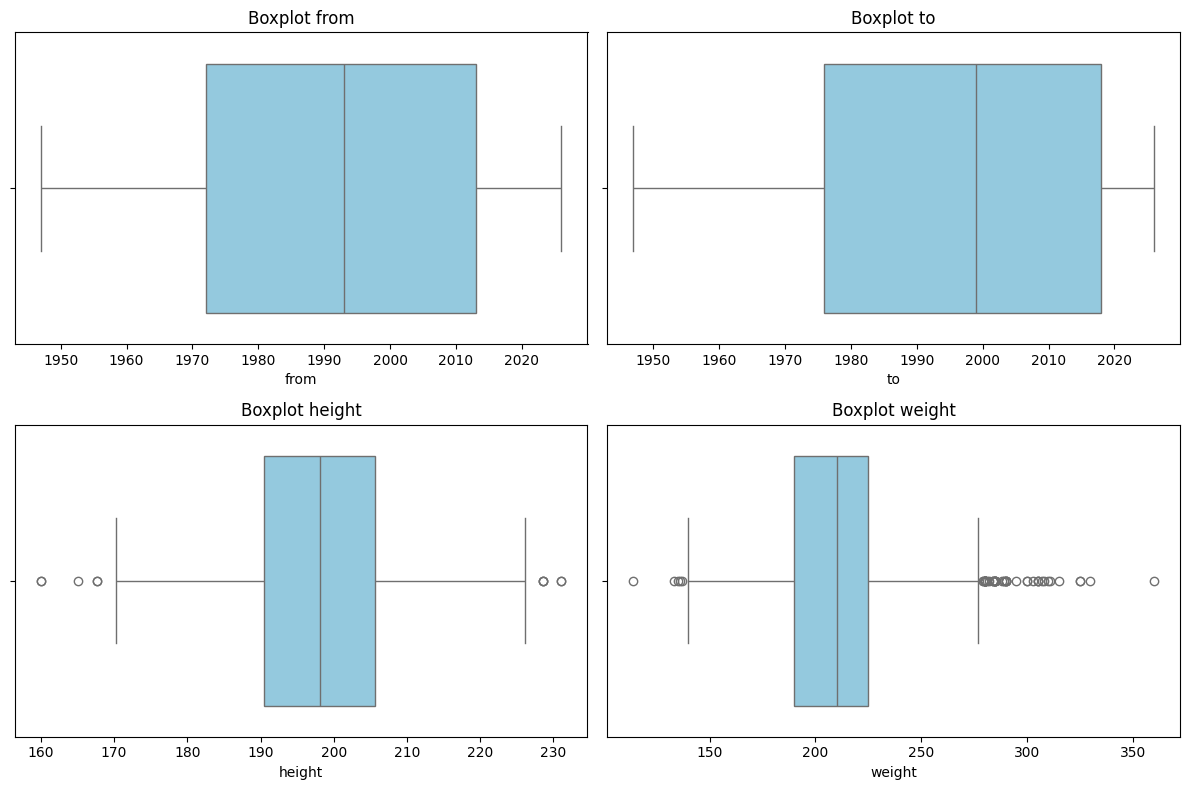

In [11]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(kolom_numerik):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=df, x=col, color="skyblue")
  plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

**Yang dibaca dari output**:
1. Sesuai perkiraan sebelumnya, kolom weight memiliki outlier.
2. Kolom height memiliki outlier karena memang pada kenyataannya memang terdapat pemain yang memiliki fisik yang tidak normal baik lebih tinggi maupun lebih rendah daripada rata rata tinggi pemain di NBA.

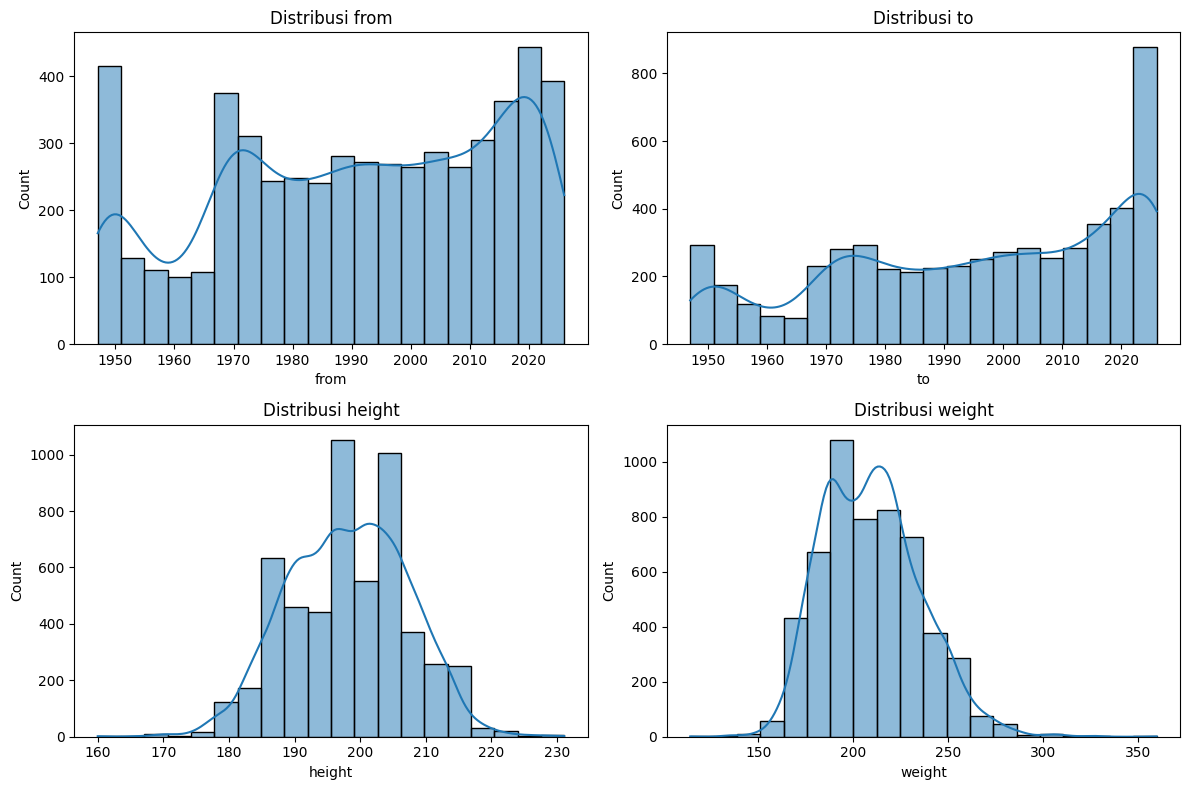

In [12]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(kolom_numerik):
  plt.subplot(2, 2, i + 1)
  sns.histplot(df[col], kde=True, bins=20)
  plt.title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

**Yang dibaca dari output:**
1. Terdapat lonjakan nilai yang cukup tinggi pada nilai 2026 di kolom to. Hal tersebut sangat wajar karena mencakup jumlah pemain aktif yang masih bermain di NBA pada tahun 2026.
2. Terdapat lonjakan nilai yang besar pada nilai 1950 pada kolom from, karena mencakup seluruh pemain pada era awal pembentukan liga.
3. Terdapat lonjakan nilai yang besar dari periode akhir 1960 an hingga awal 1970, karena adanya ekspansi dan penambahan jumlah tim di NBA.
4. Terdapat dua puncak utama (bimodal) pada kolom height di sekitar 196 cm - 198 cm (rata-rata Guard/Forward) dan 203 cm - 206 cm (rata-rata Forward/Center).
5. Grafik weight meluruh pelan ke arah kanan hingga menyentuh angka 350+ lbs. Ini merepresentasikan sebagian kecil Center dengan bobot ekstrem di sejarah NBA.


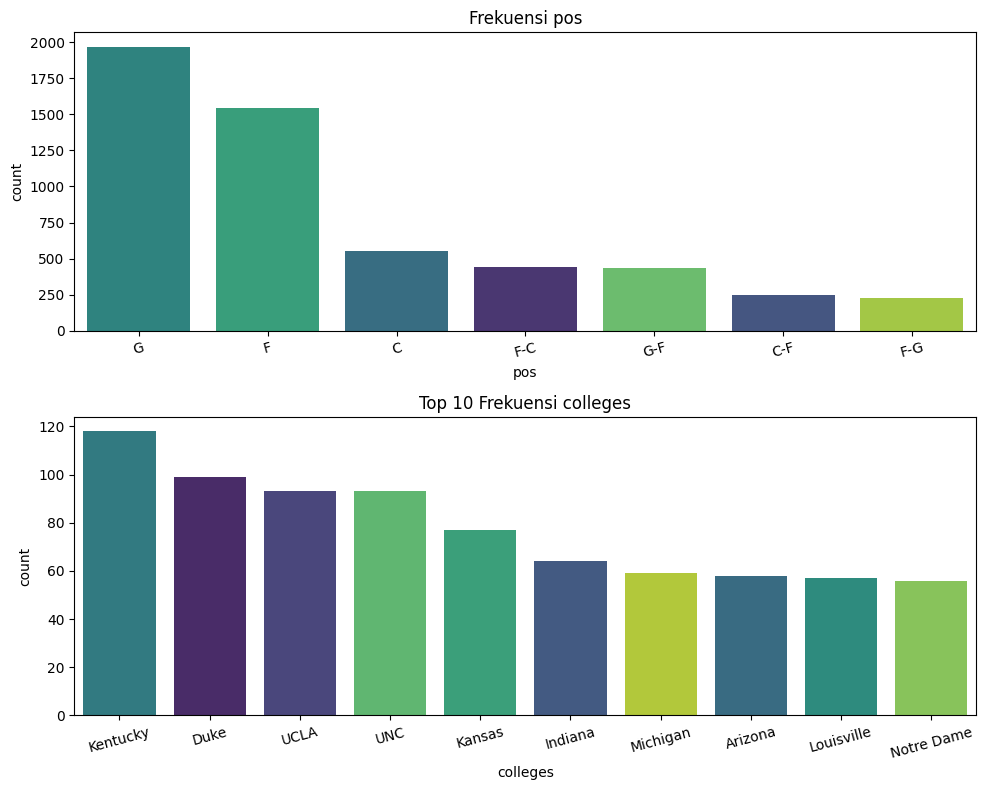

In [13]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(kolom_kategorik):
  plt.subplot(2, 1, i + 1)
  if col == "colleges":
    top10_colleges = df[col].value_counts().head(10).index
    df_top10 = df[df[col].isin(top10_colleges)]
    sns.countplot(data=df_top10, x=col, hue=col, order=top10_colleges, palette="viridis", legend=False)
    plt.xticks(rotation=15)
    plt.title(f"Top 10 Frekuensi {col}")
  else:
    sns.countplot(data=df, x=col, hue=col, order=df[col].value_counts().index, palette="viridis", legend=False)
    plt.xticks(rotation=15)
    plt.title(f"Frekuensi {col}")
plt.tight_layout()
plt.show()

**Yang dibaca dari output:**
1. Populasi pemain NBA di dominasi oleh posisi gurad murni (G) dan forward murni (F).
2. Kentucky menduduki urutan pertama sebagai kampus pencetak pemain NBA terbanyak, disusul Duke di peringkat kedua.

## Analisis Bivariat

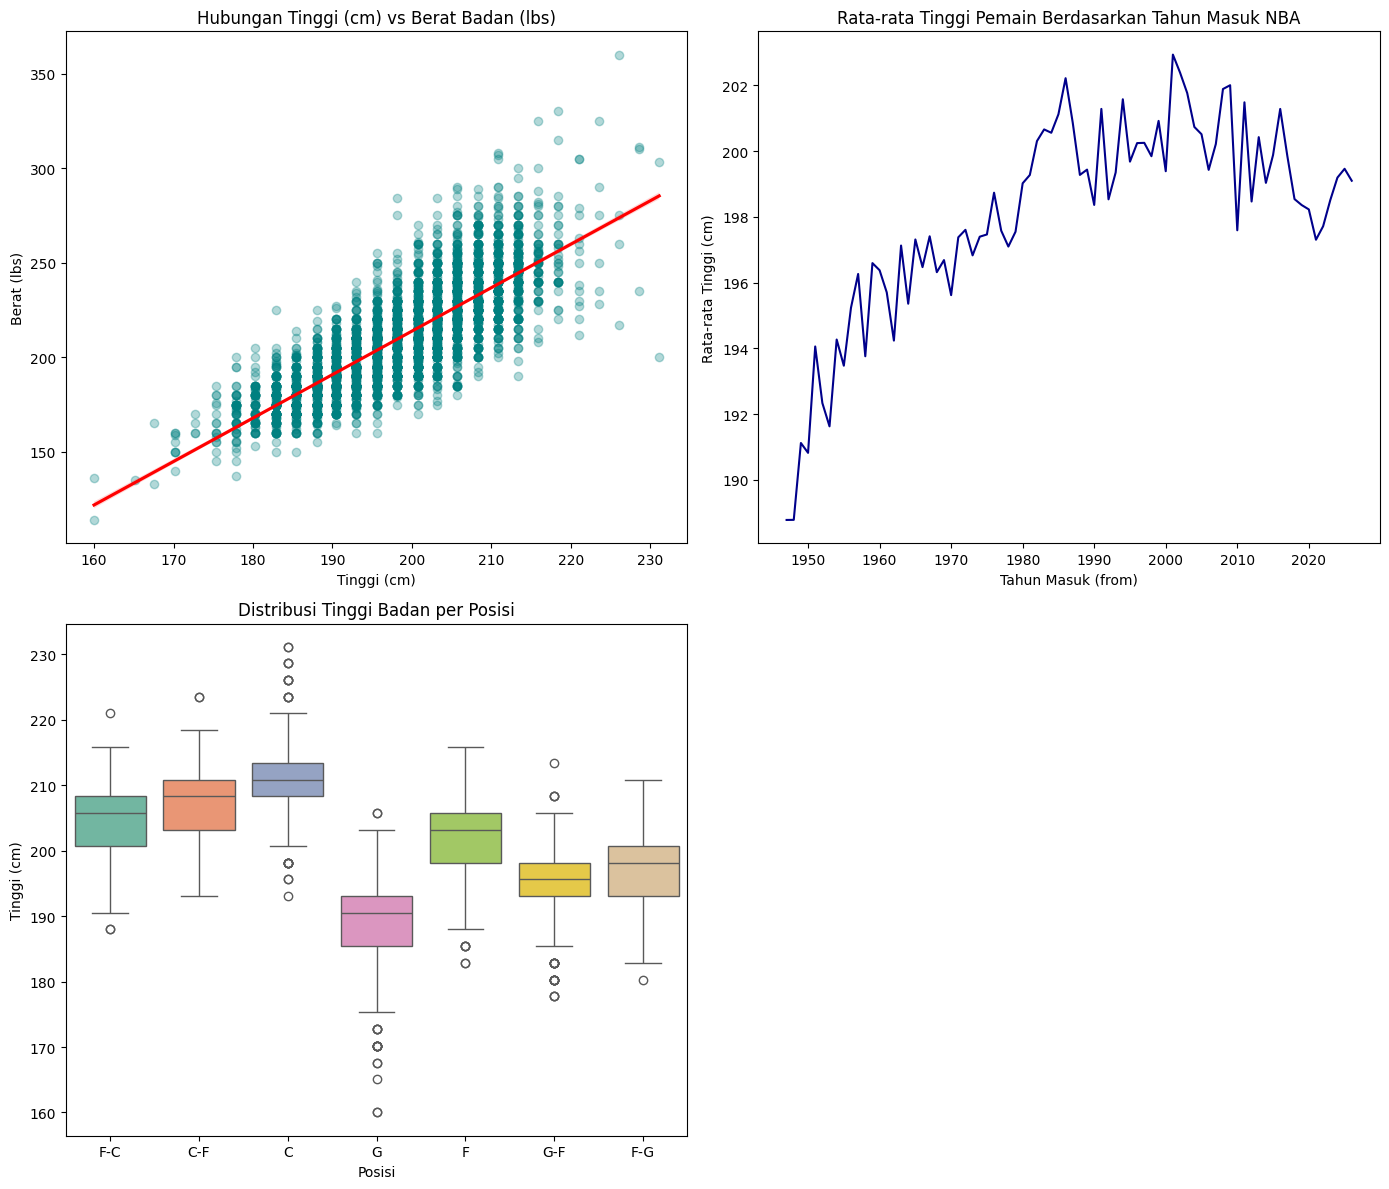

In [14]:
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
sns.regplot(data=df, x='height', y='weight', scatter_kws={'alpha': 0.3, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Hubungan Tinggi (cm) vs Berat Badan (lbs)')
plt.xlabel('Tinggi (cm)')
plt.ylabel('Berat (lbs)')

plt.subplot(2, 2, 2)
yearly_height = df.groupby('from')['height'].mean().reset_index()
sns.lineplot(data=yearly_height, x='from', y='height', color='darkblue')
plt.title('Rata-rata Tinggi Pemain Berdasarkan Tahun Masuk NBA')
plt.xlabel('Tahun Masuk (from)')
plt.ylabel('Rata-rata Tinggi (cm)')

plt.subplot(2, 2, 3)
pos_order = df.groupby('pos')['height'].median().reset_index()
sns.boxplot(data=df, x='pos', y='height', hue='pos', palette='Set2')
plt.title('Distribusi Tinggi Badan per Posisi')
plt.xlabel('Posisi')
plt.ylabel('Tinggi (cm)')

plt.tight_layout()
plt.show()

**Yang dibaca dari output**:
1. Tinggi pemain berkorelasi positif dengan berat badannya.
2. Rata-rata tinggi badan pemain NBA mengalami kenaikan tajam dari era awal (sekitar 189 cm pada tahun 1947) hingga menyentuh puncaknya di atas 202 cm pada pertengahan 1980-an (Golden Era/Big Men Era). Nilai ini kemudian perlahan menurun kembali di era modern (2010-2026) karena adanya evolusi permainan yang berfokus pada small ball dan tembakan 3 point.
3. Terdapat perbedaan fisik yang jelas di mana center memiliki nilai median paling tinggi, disusul posisi-posisi hybrid, dan guard yang memiliki median paling rendah. 

# Penanganan Missing Values

In [16]:
df['colleges'] = df['colleges'].fillna('No College / International')
df['weight'] = df.groupby('height')['weight'].transform(lambda x: x.fillna(x.median()))

print("Sisa missing values:\n", df.isna().sum())

Sisa missing values:
 player         0
from           0
to             0
pos            0
height         0
weight         0
birth_date    10
colleges       0
dtype: int64


**Pembahasan**:
1. Nilai kosong pada colleges kemungkinan terjadi karena pemain yang langsung bermain setelah lulus SMA (seperti Lebron James dan Kobe Bryant) atau pemain internasional (seperti Luka Doncic dan Nikola Jokic), sehingga penanganannya adalah dengan menambah kategori baru yaitu No College/International.
2. 5 missing values pada kolom weight ditangani dengan mengisi nilai kosong tersebut dengan nilai median berdasarkan tinggi badan karena dari analisis bivariat dapat diketahui bahwa height dan weight berkorelasi tinggi.
3. Missing values pada kolom birth_date dibiarkan karena mengisinya dengan tanggal lahir palsu (seperti tanggal 1 Januari) akan menimbulkan bias pada analisis atribut, sedangkan menghapus barisnya akan membuang informasi valid lainnya dari pemain tersebut. Di samping itu, variabel ini bersifat opsional dan tidak mengganggu proses statistik deskriptif utama.